# Plotting and Visualization

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
PREVIOUS_MAX_ROWS = pd.options.display.max_rows
pd.options.display.max_rows = 20
np.random.seed(12345)
import matplotlib.pyplot as plt
import matplotlib
plt.rc('figure', figsize=(10, 6))
np.set_printoptions(precision=4, suppress=True)

%matplotlib notebook

## A Brief matplotlib API Primer

In [2]:
import matplotlib.pyplot as plt

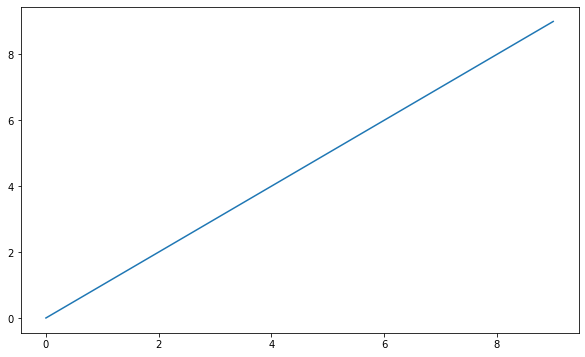

In [3]:
import numpy as np
data = np.arange(10)
data
plt.plot(data)

In [2]:
%matplotlib notebook

<IPython.core.display.Javascript object>


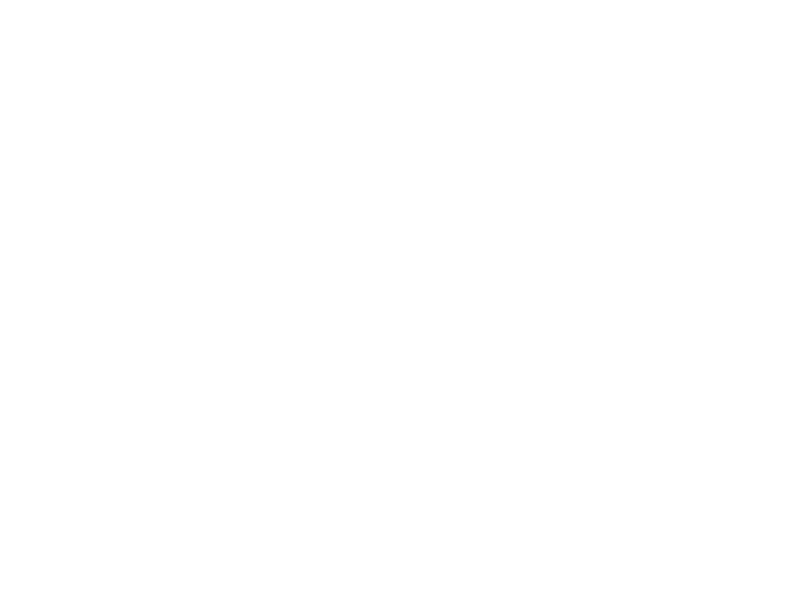

In [5]:
import numpy as np
data = np.arange(10)
data
plt.plot(data)

While libraries like seaborn and pandas’s built-in plotting functions will deal with
many of the mundane details of making plots, should you wish to customize them
beyond the function options provided, you will need to learn a bit about the **matplotlib
API.**

### Figures and Subplots

Plots in matplotlib reside within a Figure object. You can create a new figure with
`plt.figure`:

<IPython.core.display.Javascript object>


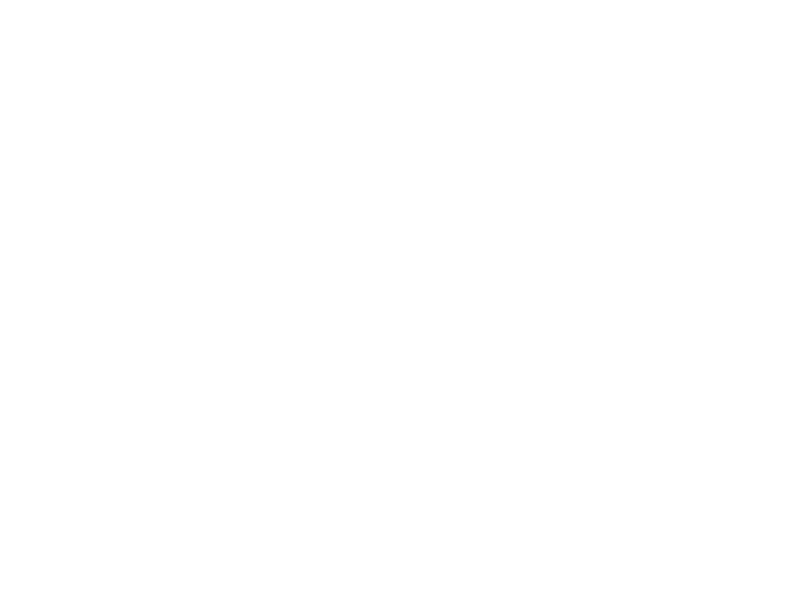

In [6]:
fig = plt.figure()

In [7]:
ax1 = fig.add_subplot(2, 2, 1)

In [8]:
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

<IPython.core.display.Javascript object>


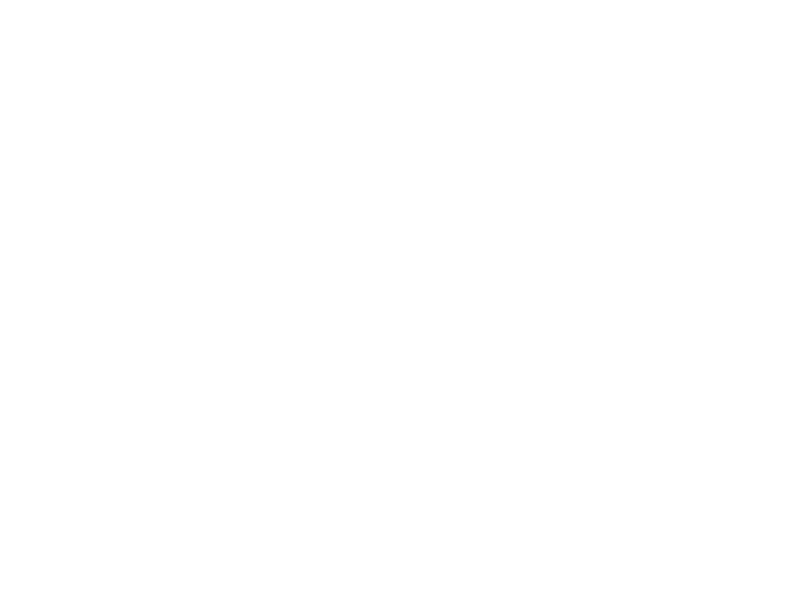

In [9]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

When you issue a plotting command like plt.plot([1.5, 3.5, -2, 1.6]), matplotlib
draws on **the last figure and subplot used** (creating one if necessary), thus hiding
the figure and subplot creation. So if we add the following command, you’ll get
something like Figure 9-3:

In [10]:
plt.plot(np.random.randn(50).cumsum(), 'k--')

The `'k--'` is a style option instructing matplotlib to plot a black dashed line. The
objects returned by `fig.add_subplot` here are `AxesSubplot` objects, on which you
can directly plot on the other empty subplots by calling each one’s instance method

In [11]:
_ = ax1.hist(np.random.randn(100), bins=20, color='k', alpha=0.3)
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.randn(30))

In [12]:
plt.close('all')

Creating a figure with a grid of subplots is a very common task, so matplotlib
includes a convenience method, `plt.subplots`, that creates a new figure and returns
a NumPy array containing the created **subplot objects**:

<IPython.core.display.Javascript object>


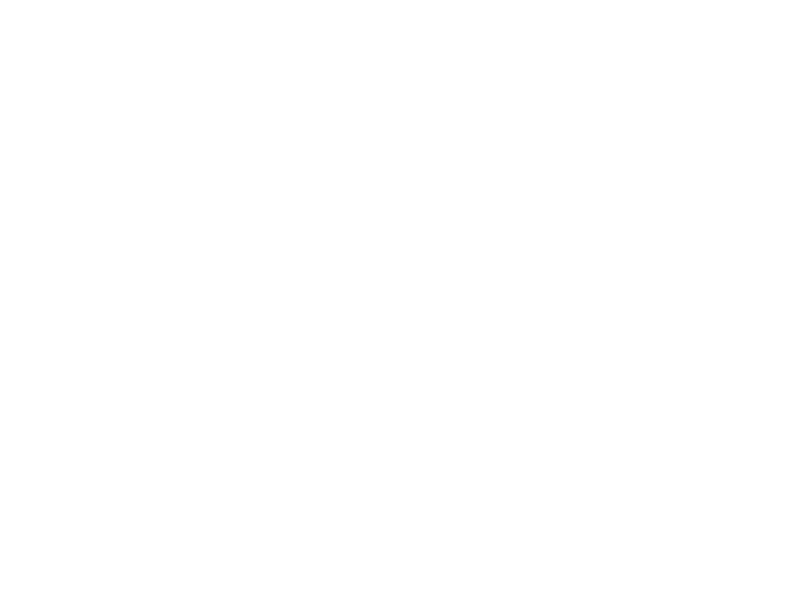

array([[<AxesSubplot:>, <AxesSubplot:>],
       [<AxesSubplot:>, <AxesSubplot:>]], dtype=object)

In [13]:
fig, axes = plt.subplots(2, 2, sharex=True)
axes

In [14]:
#ลองเอง # ทำให้ได้ผลลัพธ์เหมือน plot อันก่อนหน้า
axes[0, 0].hist(np.random.randn(100), bins=20, color='k', alpha=0.3)
axes[0, 1].scatter(np.arange(30), np.arange(30) + 3 * np.random.randn(30))
axes[1, 0].plot(np.random.randn(50).cumsum(), 'k--')

![](chan_folder/subplots.png)

#### Adjusting the spacing around subplots

By default matplotlib leaves a certain amount of padding around the outside of the
subplots and spacing between subplots. This spacing is all specified relative to the
height and width of the plot, so that if you resize the plot either programmatically or
manually using the GUI window, the plot will dynamically adjust itself. You can
change the spacing using the `subplots_adjust` method on Figure objects, also available
as a top-level function:

subplots_adjust(left=None, bottom=None, right=None, top=None,
                wspace=None, hspace=None)

`wspace` and `hspace` controls the percent of the figure width and figure height, respectively,
to use as spacing between subplots. Here is a small example where I shrink the
spacing all the way to zero (see Figure 9-5):

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.randn(500), bins=50, color='k', alpha=0.5)
plt.subplots_adjust(wspace=0, hspace=0)

<IPython.core.display.Javascript object>


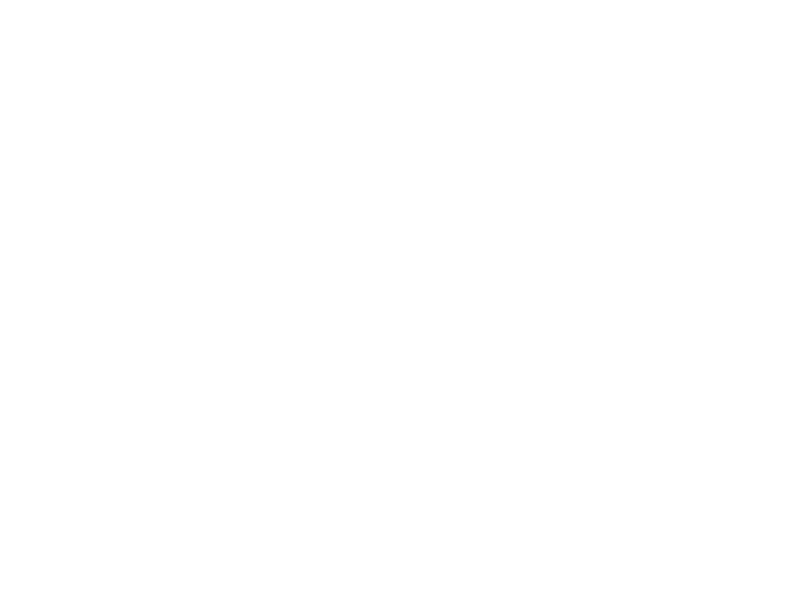

In [15]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.randn(500), bins=50, color='k', alpha=0.5)

In [16]:
plt.subplots_adjust(wspace=0, hspace=0)
#plt.subplots_adjust(wspace=0.5, hspace=0.5)
#plt.subplots_adjust(wspace=1, hspace=1)

You may notice that the axis labels overlap. matplotlib doesn’t check whether the
labels overlap, so in a case like this you would need to fix the labels yourself by specifying
**explicit tick locations and tick labels** (we’ll look at how to do this in the following
sections).

### Colors, Markers, and Line Styles

ax.plot(x, y, 'g--')

ax.plot(x, y, linestyle='--', color='g')

In [17]:
ax1.plot?

<IPython.core.display.Javascript object>


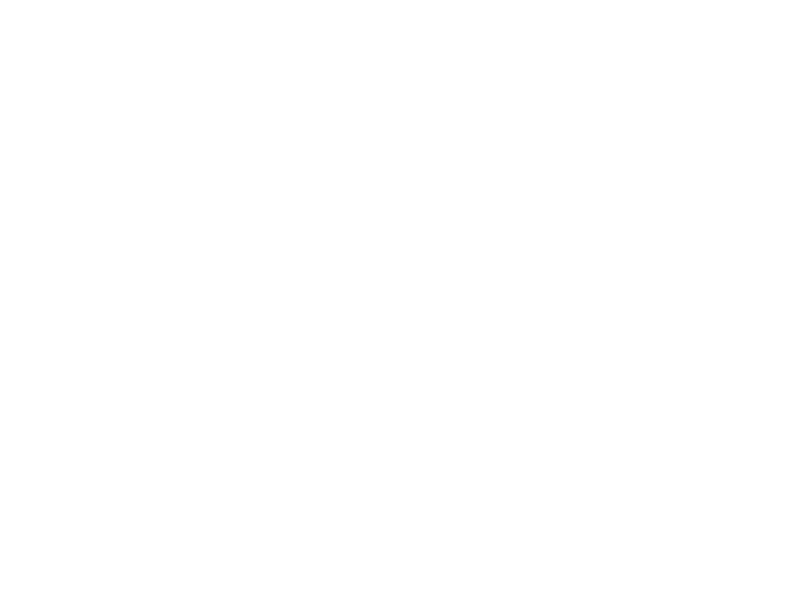

In [18]:
my_fig = plt.figure()

In [19]:
from numpy.random import randn
my_ax1 = my_fig.add_subplot(2,1,1)
my_ax2 = my_fig.add_subplot(2,1,2)


In [20]:
my_ax1.clear(); my_ax2.clear()
my_ax1.plot(randn(30).cumsum(), 'ko--')
my_ax2.plot(randn(30).cumsum(), 'bD-.')

plot(randn(30).cumsum(), color='k', linestyle='dashed', marker='o')

In [21]:
plt.close('all')

<IPython.core.display.Javascript object>


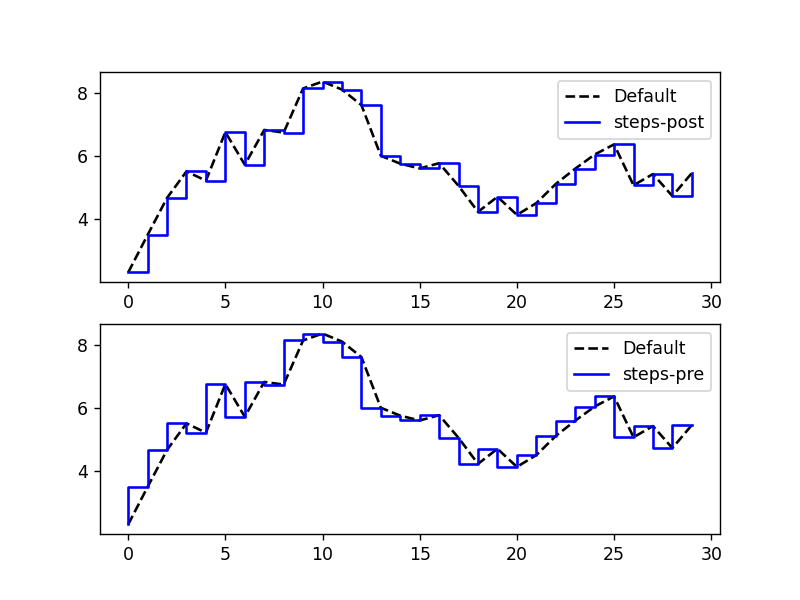

In [22]:
data = np.random.randn(30).cumsum()
her_fig, her_axes = plt.subplots(2, 1)

In [23]:
#post #pre
her_axes[0].clear(); 
her_axes[1].clear()

# เอาค่าที่่ f(5) ไป fill ในตำแหน่งหลังจาก 5
her_axes[0].plot(data, 'k--', label='Default')
her_axes[0].plot(data, 'b-', drawstyle='steps-post', label='steps-post')
her_axes[0].legend(loc='best')

# เอาค่าที่่ f(5) ไป fill ในตำแหน่งก่อนถึง 5
her_axes[1].plot(data, 'k--', label='Default')
her_axes[1].plot(data, 'b-', drawstyle='steps-pre', label='steps-pre')
her_axes[1].legend(loc='best')

# from book
# plt.legend(loc='best')

Here, since we passed the `label`
arguments to `plot`, we are able to create a plot legend to identify each line using
`plt.legend`.


>You must call plt.legend (or ax.legend, if you have a reference to
the axes) to create the legend, whether or not you passed the label
options when plotting the data.

### Ticks, Labels, and Legends

For most kinds of plot decorations, there are two main ways to do things: using the
procedural `pyplot` interface (i.e., `matplotlib.pyplot`) and the more object-oriented
native matplotlib API.

The pyplot interface, designed for interactive use, consists of methods like `xlim,
xticks, and xticklabels`. These control the plot range, tick locations, and tick labels,
respectively. They can be used in two ways:
- Called with no arguments returns the current parameter value (e.g., `plt.xlim()`
returns the current x-axis plotting range)
- Called with parameters sets the parameter value (e.g., `plt.xlim([0, 10]`), sets
the x-axis range to 0 to 10)



All such methods act on the active or most recently created `AxesSubplot`. Each of
them corresponds to two methods on the subplot object itself; in the case of `xlim`
these are `ax.get_xlim` and `ax.set_xlim`. I prefer to use the subplot instance methods
myself in the interest of being explicit (and especially when working with multiple
subplots), but you can certainly use whichever you find more convenient.


#### Setting the title, axis labels, ticks, and ticklabels

<IPython.core.display.Javascript object>


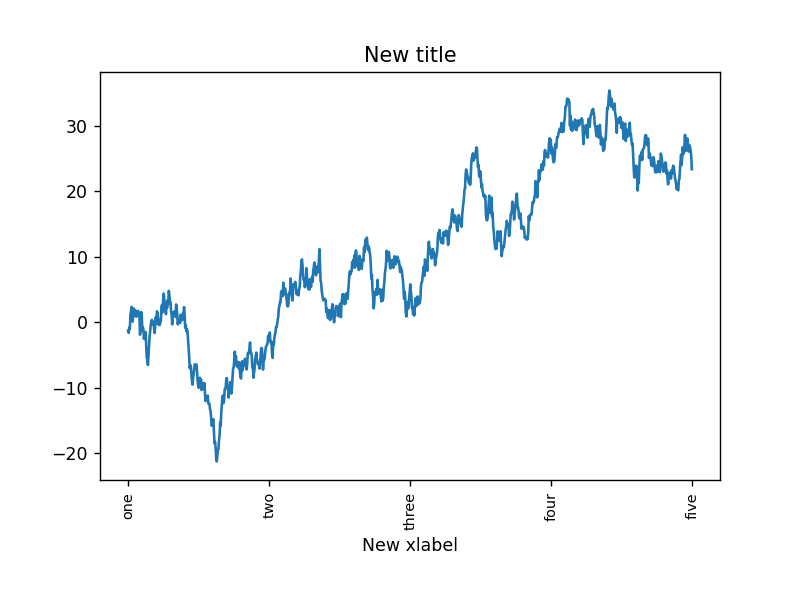

In [24]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(np.random.randn(1000).cumsum())

In [25]:
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'],
                            rotation=90, fontsize='small') # 90 ่คือองศาของ tick labels

In [26]:
ax.set_title('My first matplotlib plot')
ax.set_xlabel('Stages')

Text(0.5, 0, 'Stages')

In [27]:
#ลองเอง #make_room #adjust
# to make room for the x-axis labels.
# ตอนแรก x-axis label ตกขอบด้าน่ล่างของรูป พอใช้ subplots_adjust ก็แก้ไขได้
fig.subplots_adjust(left=None, bottom=0.2, right=None, top=None, wspace=None, hspace=None)

In [28]:
props = {
    'title': 'New title',
    'xlabel': 'New xlabel'
}
ax.set(**props)

[Text(0.5, 1.0, 'New title'), Text(0.5, 0, 'New xlabel')]

#### Adding legends

<IPython.core.display.Javascript object>


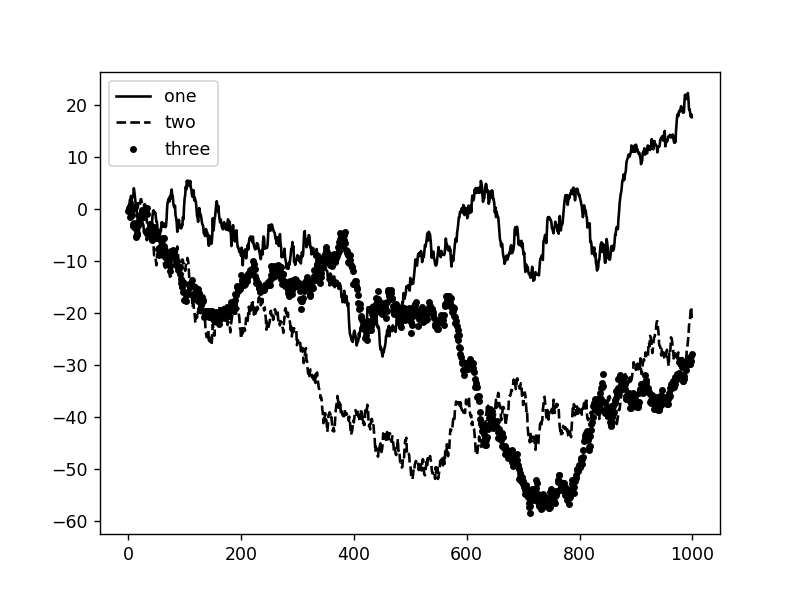

In [29]:
from numpy.random import randn
fig = plt.figure(); ax = fig.add_subplot(1, 1, 1)
ax.plot(randn(1000).cumsum(), 'k', label='one')
ax.plot(randn(1000).cumsum(), 'k--', label='two')
ax.plot(randn(1000).cumsum(), 'k.', label='three')

Once you’ve done this, you can either call `ax.legend()` or `plt.legend()` to automatically
create a legend.

In [30]:
ax.legend(loc='best')

### Annotations and Drawing on a Subplot

ax.text(x, y, 'Hello world!',
        family='monospace', fontsize=10)

<IPython.core.display.Javascript object>


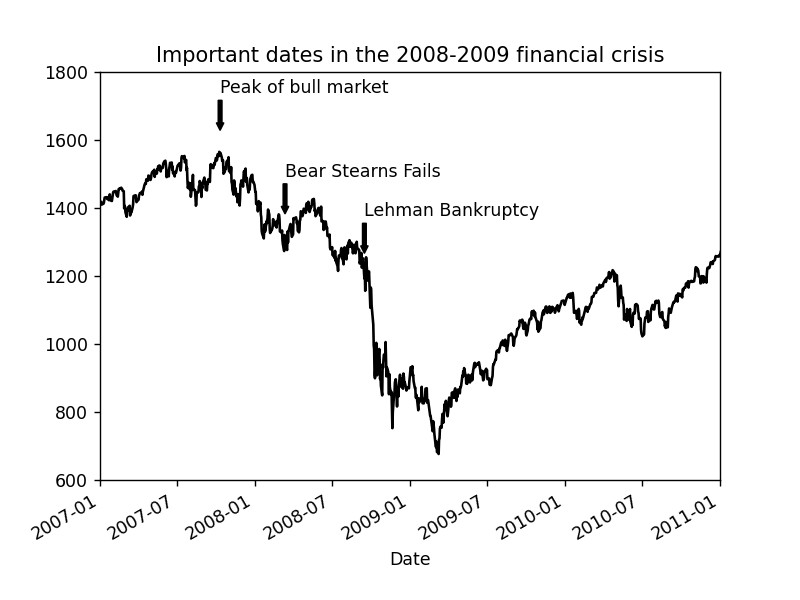

Text(0.5, 1.0, 'Important dates in the 2008-2009 financial crisis')

In [37]:
from datetime import datetime

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

data = pd.read_csv('examples/spx.csv', index_col=0, parse_dates=True)
spx = data['SPX']

spx.plot(ax=ax, style='k-')

crisis_data = [
    (datetime(2007, 10, 11), 'Peak of bull market'),
    (datetime(2008, 3, 12), 'Bear Stearns Fails'),
    (datetime(2008, 9, 15), 'Lehman Bankruptcy')
]

for date, label in crisis_data:
    ax.annotate(label, xy=(date, spx.asof(date) + 75),
                xytext=(date, spx.asof(date) + 225),
                arrowprops=dict(facecolor='black', headwidth=4, width=2,
                                headlength=4),
                horizontalalignment='left', verticalalignment='top')

# Zoom in on 2007-2010
ax.set_xlim(['1/1/2007', '1/1/2011'])
ax.set_ylim([600, 1800])

ax.set_title('Important dates in the 2008-2009 financial crisis')

In [ ]:
ax.set_title('Important dates in the 2008–2009 financial crisis')

Drawing shapes requires some more care. matplotlib has objects that represent many
common shapes, referred to as patches. Some of these, like Rectangle and Circle, are
found in `matplotlib.pyplot`, but the full set is located in `matplotlib.patches`.

To add a shape to a plot, you create the patch object shp and add it to a subplot by
calling ax.add_patch(shp):

```
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color='k', alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color='b', alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color='g', alpha=0.5)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)
```

<IPython.core.display.Javascript object>


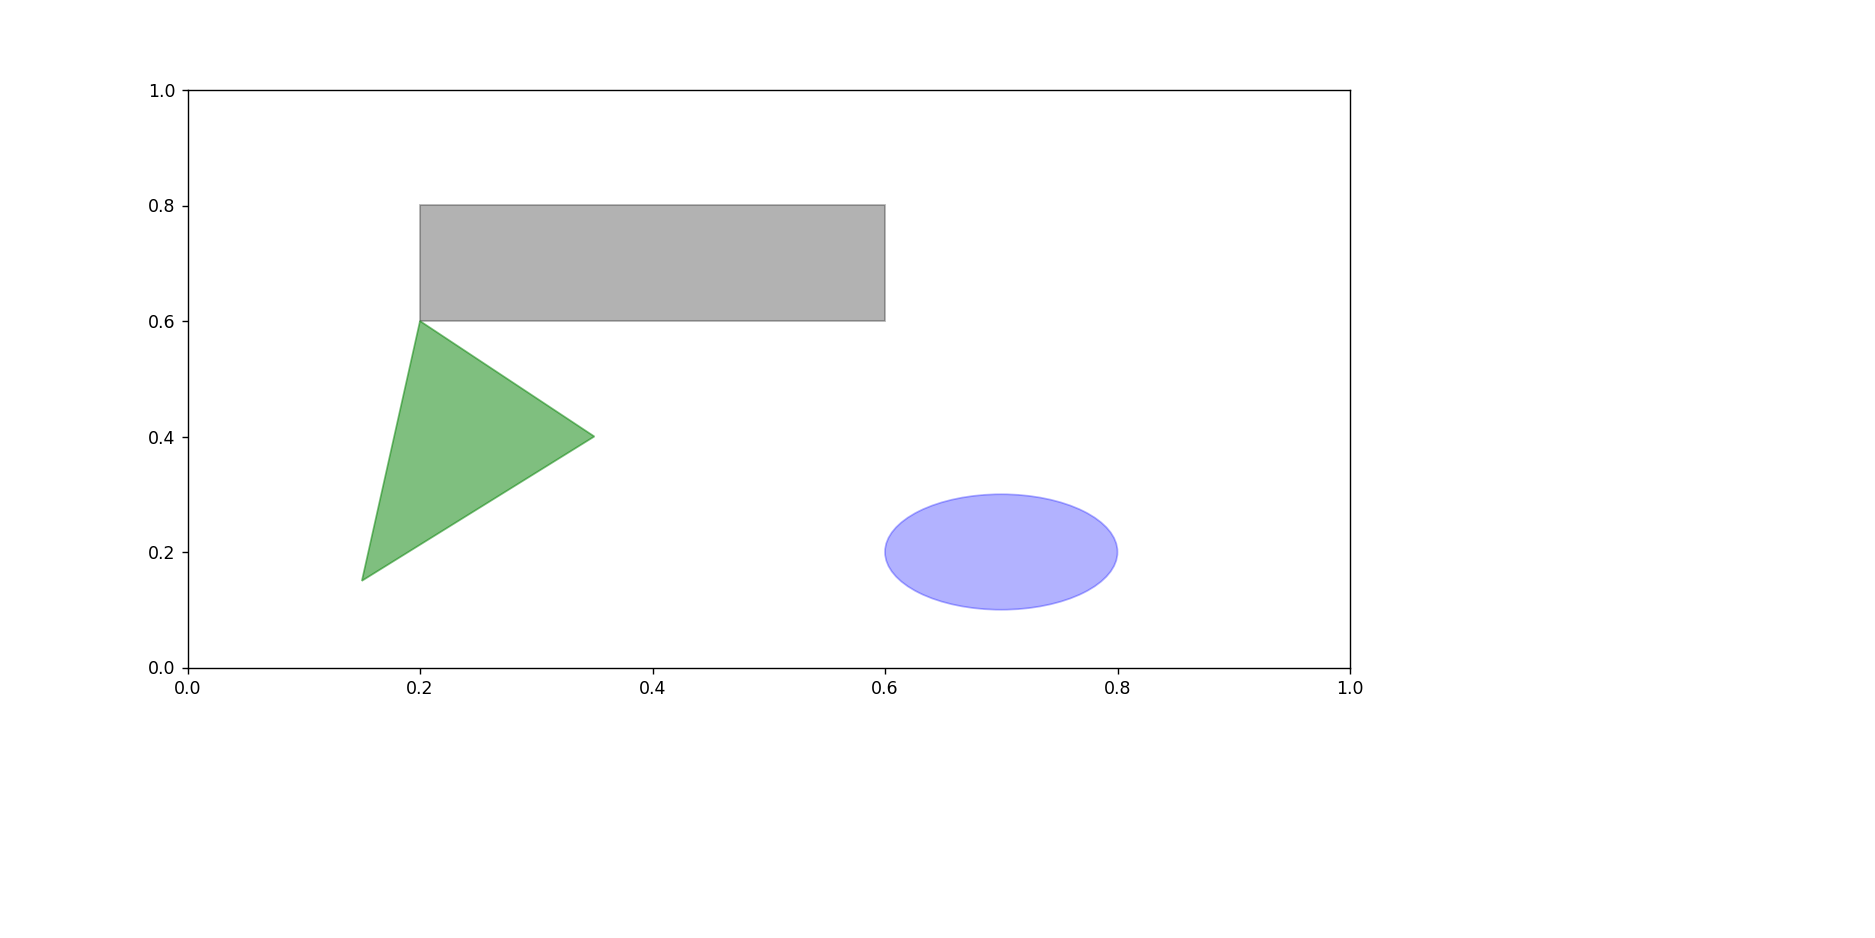

In [36]:
fig = plt.figure(figsize=(12, 6)); ax = fig.add_subplot(1, 1, 1)
rect = plt.Rectangle((0.2, 0.6), 0.4, 0.2, color='k', alpha=0.3) # 0.4 ตือความยาวด้านกว้าง(width) ส่วน 0.2 ด้านยาว(length)
circ = plt.Circle((0.7, 0.2), 0.1, color='b', alpha=0.3) # 0.1 = radius horizontally
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color='g', alpha=0.5)
ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)

### Saving Plots to File

plt.savefig('figpath.svg')

plt.savefig('figpath.png', dpi=400, bbox_inches='tight')

from io import BytesIO
buffer = BytesIO()
plt.savefig(buffer)
plot_data = buffer.getvalue()

![](chan_folder/plot_save.png)

### matplotlib Configuration

```
plt.rc('figure', figsize=(10, 10))
```

The first argument to rc is the component you wish to customize, such as 'figure',
'axes', 'xtick', 'ytick', 'grid', 'legend', or many others. After that can follow a
sequence of keyword arguments indicating the new parameters. An easy way to write
down the options in your program is as a dict:

```
font_options = {'family' : 'monospace',
                'weight' : 'bold',
                'size'   : 'small'}
plt.rc('font', **font_options)
```

#configuration_file

For more extensive customization and to see a list of all the options, matplotlib comes
with a configuration file matplotlibrc in the matplotlib/mpl-data directory. If you customize
this file and place it in your home directory titled .matplotlibrc, it will be
loaded each time you use matplotlib.

## Plotting with pandas and seaborn

matplotlib can be a fairly low-level tool. You assemble a plot from its base components:
the data display (i.e., the type of plot: line, bar, box, scatter, contour, etc.), legend,
title, tick labels, and other annotations.

In pandas we may have multiple columns of data, along with row and column labels.
pandas itself has built-in methods that simplify creating visualizations from Data‐
Frame and Series objects. Another library is seaborn, a statistical graphics library created
by Michael Waskom. Seaborn simplifies creating many common visualization
types.

>Importing seaborn modifies the default matplotlib color schemes
and plot styles to improve readability and aesthetics. Even if you do
not use the seaborn API, you may prefer to import seaborn as a
simple way to improve the visual aesthetics of general matplotlib
plots.

### Line Plots

In [40]:
plt.close('all')

By default, plot() makes line plots. 

The Series object’s index is passed to matplotlib for plotting on the x-axis, though you
can disable this by passing `use_index=False`. The x-axis ticks and limits can be
adjusted with the `xticks` and `xlim` options, and y-axis respectively with `yticks` and `ylim`.

<IPython.core.display.Javascript object>


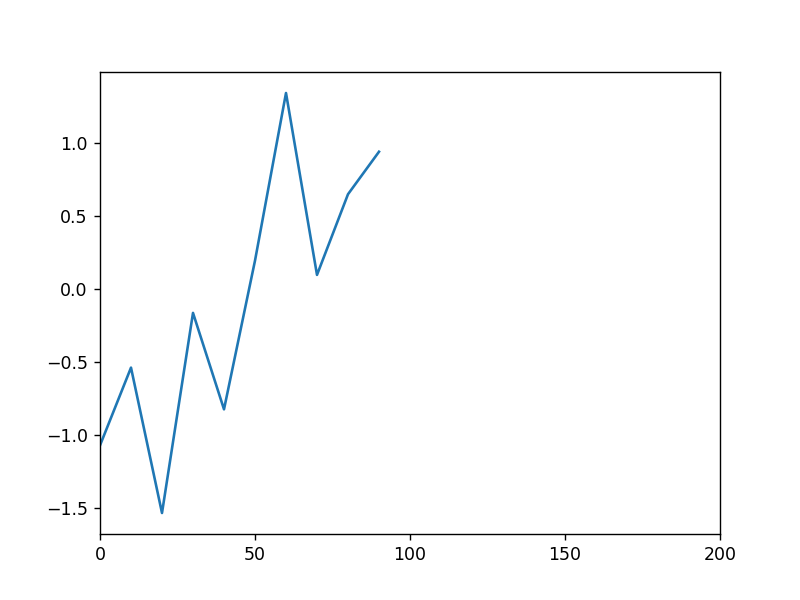

<AxesSubplot:>

In [46]:
s = pd.Series(np.random.randn(10).cumsum(), index=np.arange(0, 100, 10))
s.plot(xticks=[0, 50, 100, 150, 200], xlim=[0, 200])

<IPython.core.display.Javascript object>


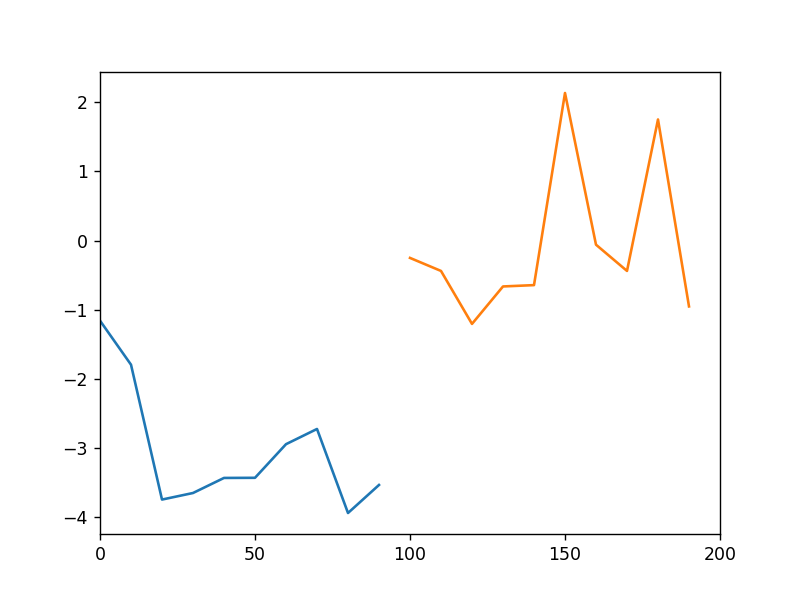

<AxesSubplot:>

In [50]:
#ลองเอง # ถ้าอยากให้ plot shared กันระหว่างสอง series.plot()
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

s1 = pd.Series(np.random.randn(10).cumsum(), index=np.arange(0, 100, 10))
s1.plot(ax=ax, xticks=[0, 50, 100, 150, 200], xlim=[0, 200])

s2 = pd.Series(np.random.randn(10), index=np.arange(100, 200, 10))
s2.plot(ax=ax)

<IPython.core.display.Javascript object>


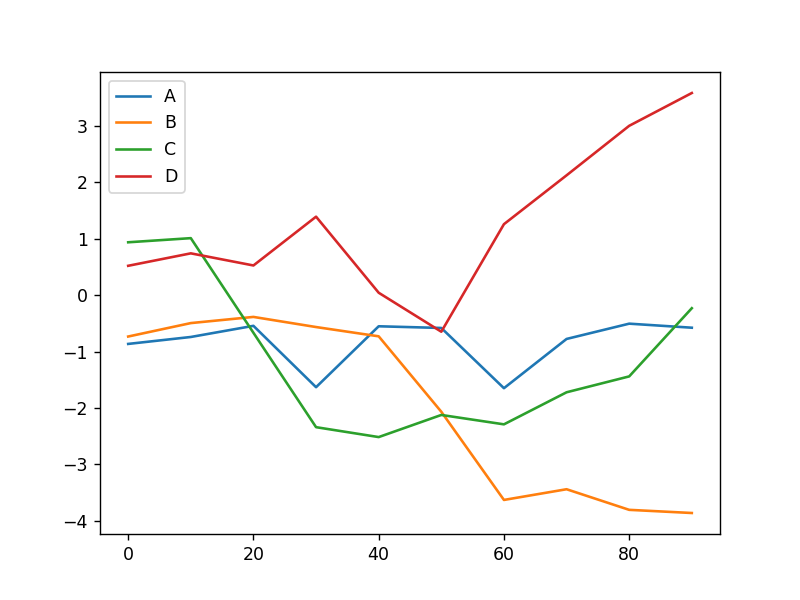

<AxesSubplot:>

In [51]:
df = pd.DataFrame(np.random.randn(10, 4).cumsum(0),
                  columns=['A', 'B', 'C', 'D'],
                  index=np.arange(0, 100, 10))
df.plot()

![](chan_folder/plot_series.png)

### Bar Plots

The plot attribute contains a “family” of methods for different plot types. For example,
`df.plot()` is equivalent to `df.plot.line()`.

the Series or DataFrame index will be used as the x (bar) or y
(barh) ticks.

<IPython.core.display.Javascript object>


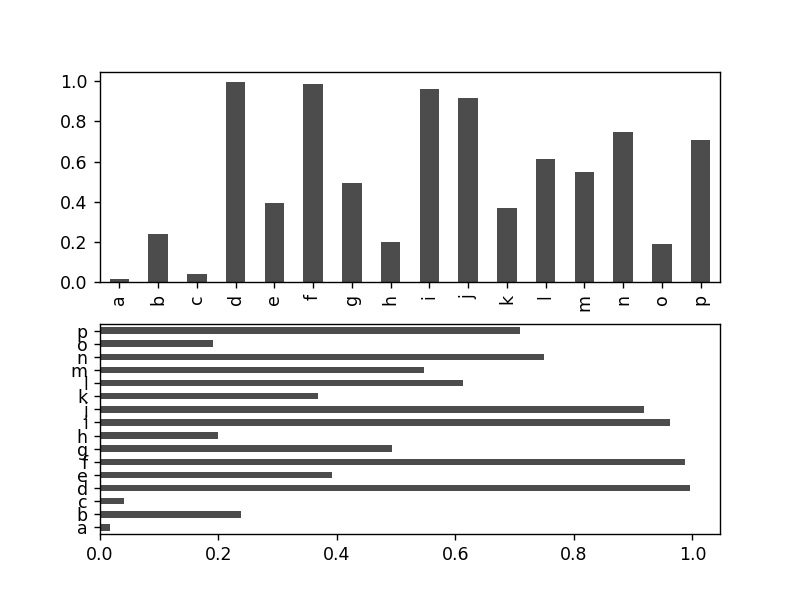

<AxesSubplot:>

In [52]:
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.rand(16), index=list('abcdefghijklmnop'))
data.plot.bar(ax=axes[0], color='k', alpha=0.7)
data.plot.barh(ax=axes[1], color='k', alpha=0.7)

With a DataFrame, bar plots group the values in each row together in a group in bars,
side by side, for each value.

In [53]:
np.random.seed(12348)

<IPython.core.display.Javascript object>


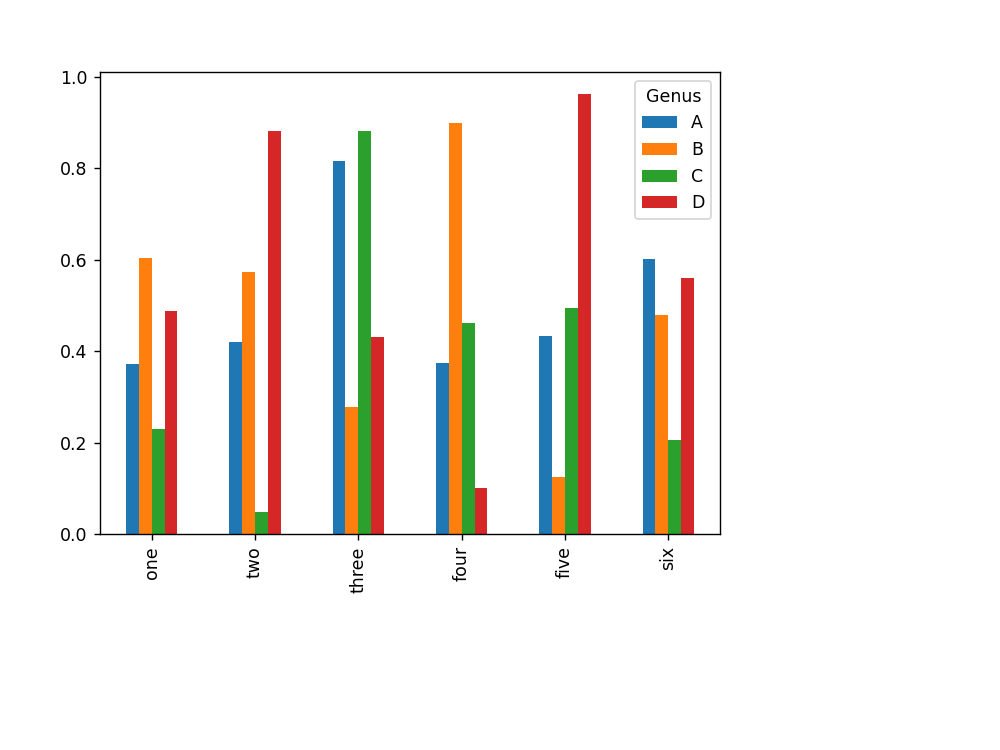

<AxesSubplot:>

In [54]:
df = pd.DataFrame(np.random.rand(6, 4),
                  index=['one', 'two', 'three', 'four', 'five', 'six'],
                  columns=pd.Index(['A', 'B', 'C', 'D'], name='Genus'))
df
df.plot.bar()
# ถ้า plot อีกแบบ(hypothetical) คือ group A มาติดๆกันเป็น time series indexed by one, two, three, ...
# ซึ่งเนื่องจากมี 4 columns  การปรากฎตัว ของindex: one, two, three, ... ก็จะเกิดขึ้น 4 ครั้ง

<IPython.core.display.Javascript object>


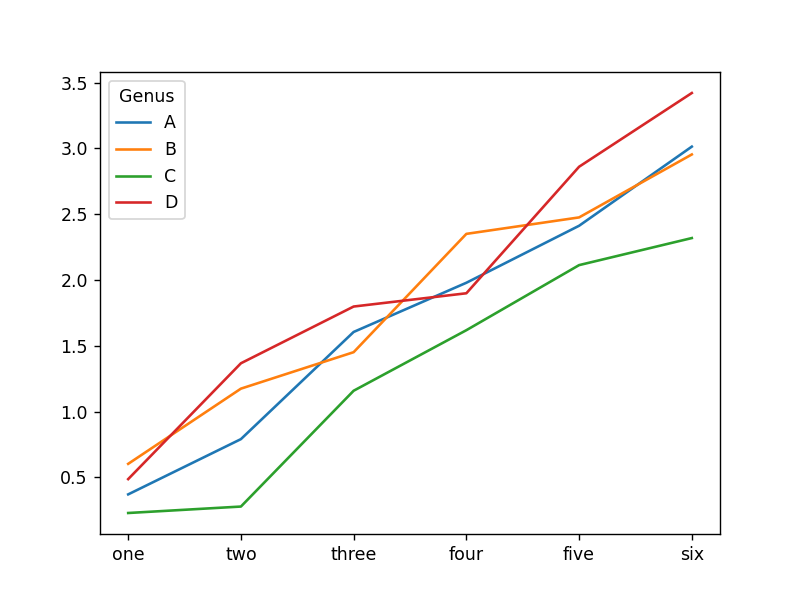

<AxesSubplot:>

In [59]:
#ลองเอง
df.cumsum(0).plot()

<IPython.core.display.Javascript object>


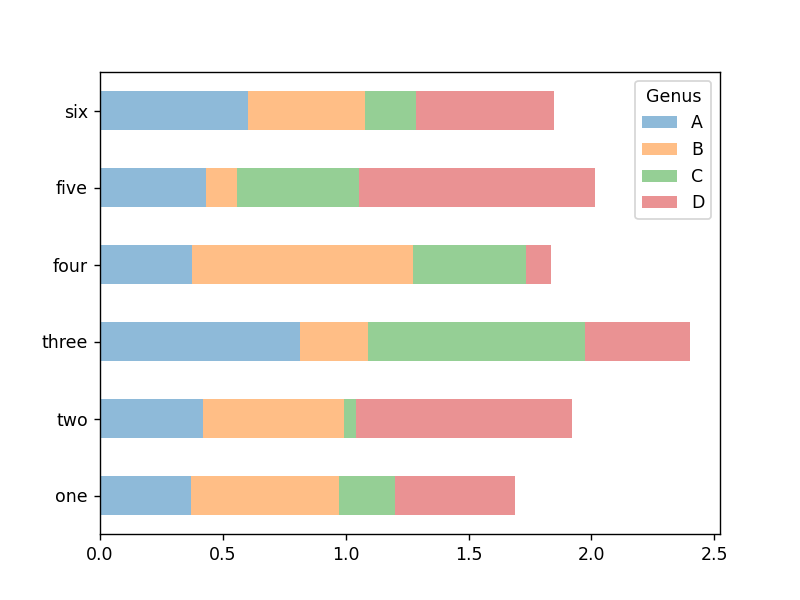

<AxesSubplot:>

In [61]:
df.plot.barh(stacked=True, alpha=0.5)

In [62]:
plt.close('all')

In [3]:
tips = pd.read_csv('examples/tips.csv')
print(tips, '\n')
# ดูว่า crosstab คืออะไรได้ที่ https://medium.com/@whyamit404/understanding-pandas-crosstab-with-simple-examples-90cf6ea5a9a1
party_counts = pd.crosstab(tips['day'], tips['size'])
print(party_counts)
# Not many 1- and 6-person parties
party_counts = party_counts.loc[:, 2:5] # label-based
party_counts

     total_bill   tip smoker   day    time  size
0         16.99  1.01     No   Sun  Dinner     2
1         10.34  1.66     No   Sun  Dinner     3
2         21.01  3.50     No   Sun  Dinner     3
3         23.68  3.31     No   Sun  Dinner     2
4         24.59  3.61     No   Sun  Dinner     4
..          ...   ...    ...   ...     ...   ...
239       29.03  5.92     No   Sat  Dinner     3
240       27.18  2.00    Yes   Sat  Dinner     2
241       22.67  2.00    Yes   Sat  Dinner     2
242       17.82  1.75     No   Sat  Dinner     2
243       18.78  3.00     No  Thur  Dinner     2

[244 rows x 6 columns] 

size  1   2   3   4  5  6
day                      
Fri   1  16   1   1  0  0
Sat   2  53  18  13  1  0
Sun   0  39  15  18  3  1
Thur  1  48   4   5  1  3


size,2,3,4,5
day,,,,
Fri,16,1,1,0
Sat,53,18,13,1
Sun,39,15,18,3
Thur,48,4,5,1


<IPython.core.display.Javascript object>


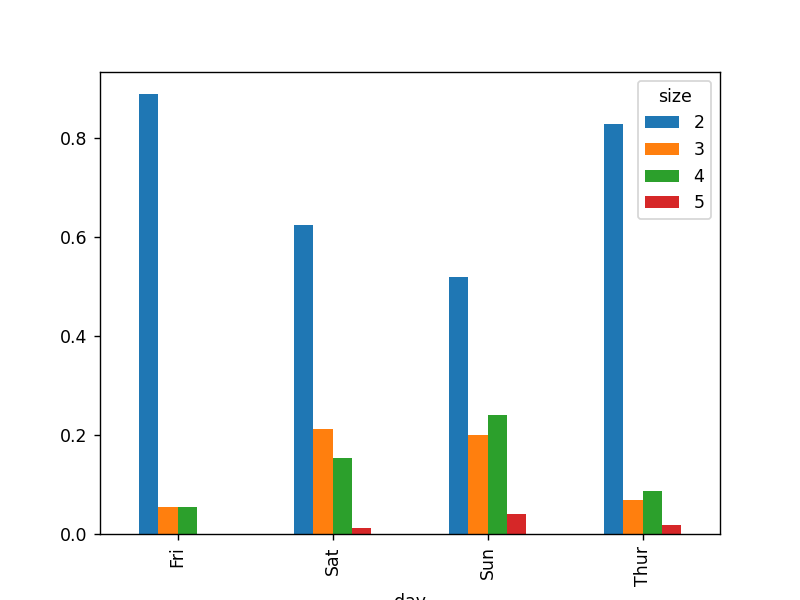

<AxesSubplot:xlabel='day'>

In [66]:
# Normalize to sum to 1
party_pcts = party_counts.div(party_counts.sum(1), axis=0) # sum(1) rows -> are retained, axis=0 -> match on row
party_pcts
party_pcts.plot.bar()

In [67]:
plt.close('all')

   total_bill   tip smoker  day    time  size   tip_pct
0       16.99  1.01     No  Sun  Dinner     2  0.063204
1       10.34  1.66     No  Sun  Dinner     3  0.191244
2       21.01  3.50     No  Sun  Dinner     3  0.199886
3       23.68  3.31     No  Sun  Dinner     2  0.162494
4       24.59  3.61     No  Sun  Dinner     4  0.172069


<IPython.core.display.Javascript object>


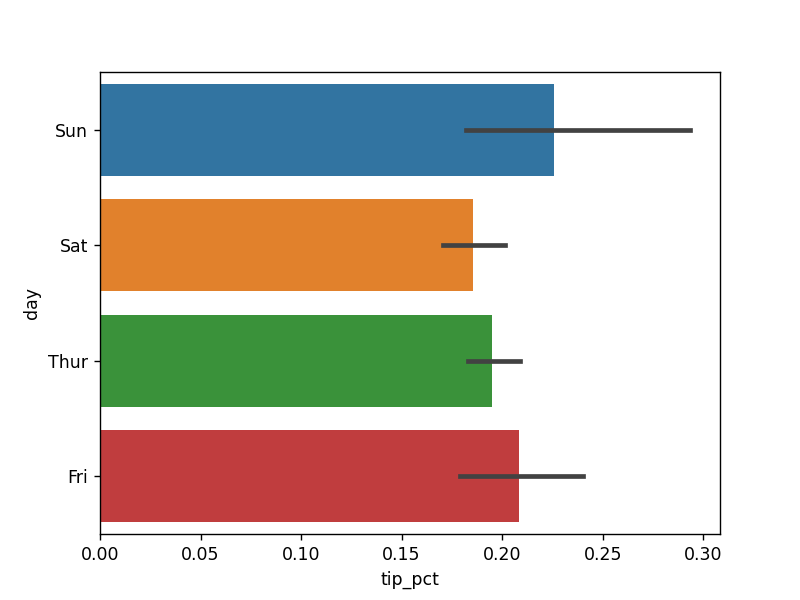

<AxesSubplot:xlabel='tip_pct', ylabel='day'>

In [4]:
import seaborn as sns
tips['tip_pct'] = tips['tip'] / (tips['total_bill'] - tips['tip'])
print(tips.head())
sns.barplot(x='tip_pct', y='day', data=tips, orient='h')

Plotting functions in seaborn take a data argument, which can be a pandas Data‐
Frame. The other arguments refer to column names. **Because there are multiple
observations for each value in the day, the bars are the average value of tip_pct**. The
black lines drawn on the bars represent the 95% confidence interval (this can be configured
through optional arguments).

In [5]:
plt.close('all')

`seaborn.barplot` has a `hue` option that enables us to split by an additional categorical
value

<IPython.core.display.Javascript object>


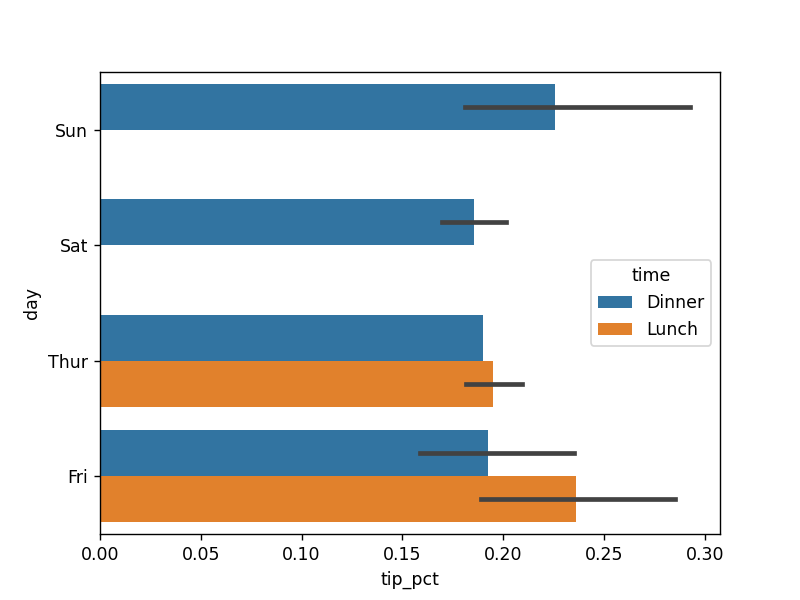

<AxesSubplot:xlabel='tip_pct', ylabel='day'>

In [6]:
sns.barplot(x='tip_pct', y='day', hue='time', data=tips, orient='h')

In [7]:
plt.close('all')

Notice that seaborn has automatically changed the aesthetics of plots: the default
color palette, plot background, and grid line colors. You can switch between different
plot appearances using `seaborn.set`:

In [71]:
sns.set(style="whitegrid")

### Histograms and Density Plots

A histogram is a kind of bar plot that gives a discretized display of value frequency.
The data points are split into discrete, evenly spaced bins, and the number of data
points in each bin is plotted. Using the tipping data from before, we can make a histogram
of tip percentages of the total bill using the `plot.hist` method on the Series

<IPython.core.display.Javascript object>


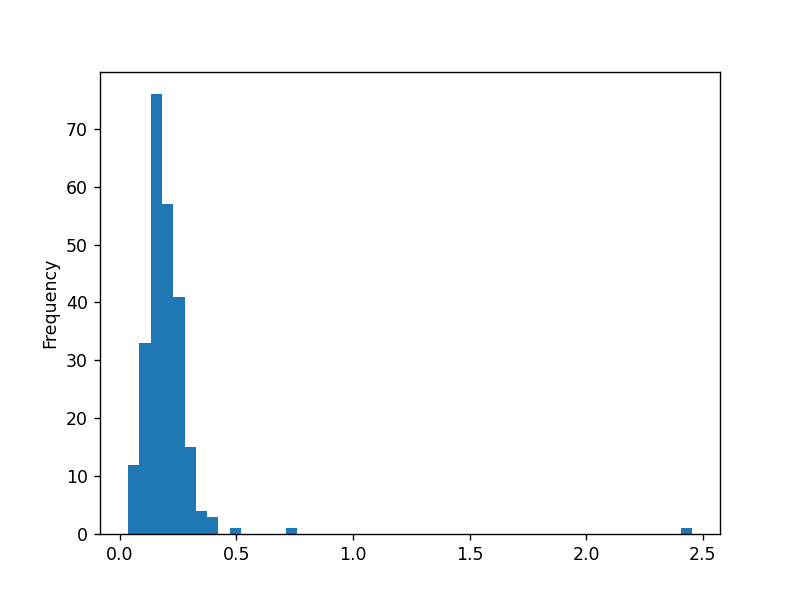

In [8]:
plt.figure();

In [9]:
tips['tip_pct'].plot.hist(bins=50)

<AxesSubplot:ylabel='Frequency'>

A related plot type is a density plot, which is formed by computing an estimate of a
continuous probability distribution that might have generated the observed data. The
usual procedure is to approximate this distribution as a mixture of “kernels”—that is,
simpler distributions like the normal distribution. Thus, density plots are also known
as kernel density estimate (KDE) plots. Using `plot.kde` makes a density plot using
the conventional mixture-of-normals estimate

<IPython.core.display.Javascript object>


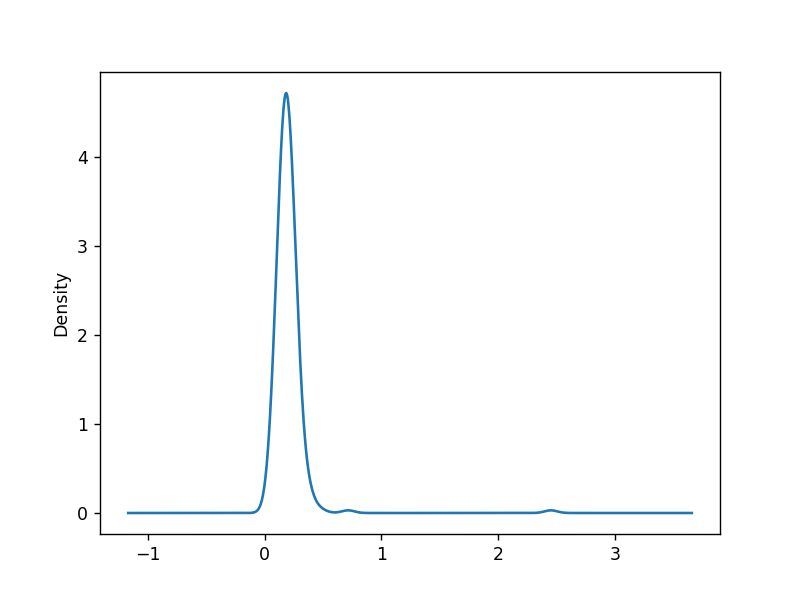

In [11]:
plt.figure();

In [12]:
tips['tip_pct'].plot.density()

<AxesSubplot:ylabel='Density'>

Seaborn makes histograms and density plots even easier through its `distplot`
method, which can plot both a histogram and a continuous density estimate simultaneously.
As an example, consider a bimodal distribution consisting of draws from
two different standard normal distributions

<IPython.core.display.Javascript object>


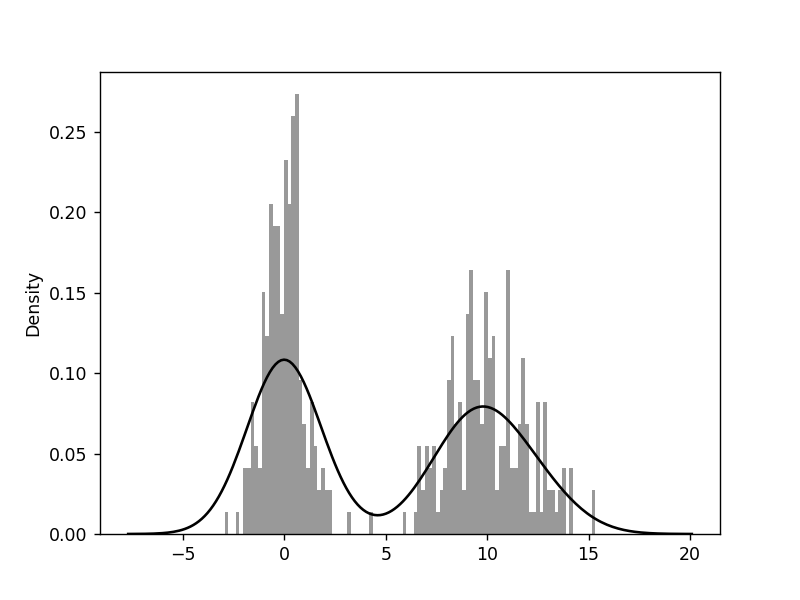

In [15]:
plt.figure();

In [16]:
comp1 = np.random.normal(0, 1, size=200)
comp2 = np.random.normal(10, 2, size=200)
values = pd.Series(np.concatenate([comp1, comp2]))
sns.distplot(values, bins=100, color='k')

C:\Users\Lenovo\miniconda3\envs\4book\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:ylabel='Density'>

### Scatter or Point Plots

Point plots or scatter plots can be a useful way of examining the relationship between
two one-dimensional data series. For example, here we load the `macrodata` dataset
from the statsmodels project, select a few variables, then compute log differences:

In [17]:
macro = pd.read_csv('examples/macrodata.csv')
data = macro[['cpi', 'm1', 'tbilrate', 'unemp']]
trans_data = np.log(data).diff().dropna()
trans_data[-5:]

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


In [30]:
#ลองเอง ทดสอบใช้ .diff()
x = pd.DataFrame({0:[ 1, 2, 2, 4], 1:[-1, -2, -2, -4]})
print(x, '\n')
print(x.diff(), '\n')
print(x.shift(1), '\n')
pd.concat([x.diff(), x - x.shift(1)], axis=1, keys=['lib version', 'my version'])

   0  1
0  1 -1
1  2 -2
2  2 -2
3  4 -4 

     0    1
0  NaN  NaN
1  1.0 -1.0
2  0.0  0.0
3  2.0 -2.0 

     0    1
0  NaN  NaN
1  1.0 -1.0
2  2.0 -2.0
3  2.0 -2.0 



lib version      my version     
            0    1          0    1
0         NaN  NaN        NaN  NaN
1         1.0 -1.0        1.0 -1.0
2         0.0  0.0        0.0  0.0
3         2.0 -2.0        2.0 -2.0

<IPython.core.display.Javascript object>


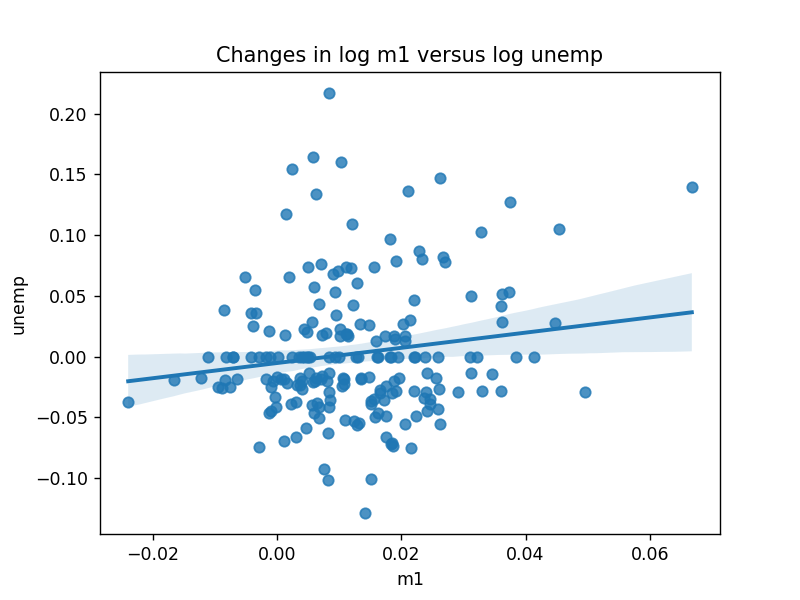

In [21]:
plt.figure();

We can then use seaborn’s `regplot` method, which makes a scatter plot and fits a linear
regression line

In [22]:
sns.regplot(x='m1', y='unemp', data=trans_data)
plt.title('Changes in log %s versus log %s' % ('m1', 'unemp'))

Text(0.5, 1.0, 'Changes in log m1 versus log unemp')

In exploratory data analysis it’s helpful to be able to look at all the scatter plots among
a group of variables; this is known as a *pairs plot* or *scatter plot matrix*. Making such a
plot from scratch is a bit of work, so seaborn has a convenient `pairplot` function,
which supports placing histograms or density estimates of each variable along the
diagonal

<IPython.core.display.Javascript object>


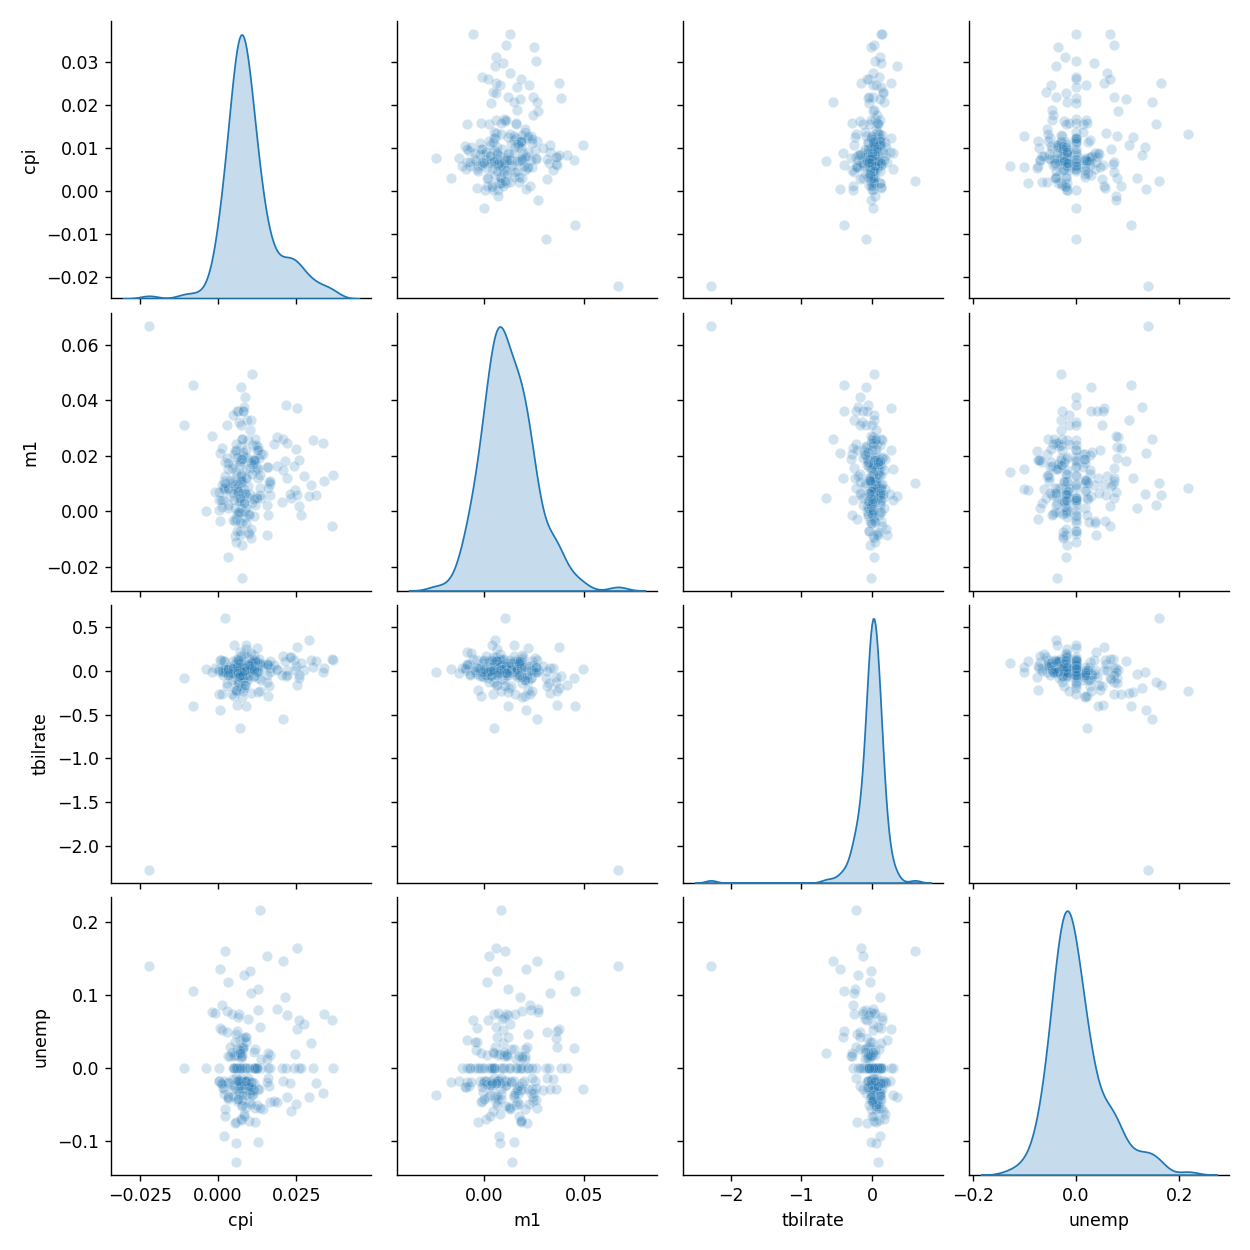

In [23]:
sns.pairplot(trans_data, diag_kind='kde', plot_kws={'alpha': 0.2})

You may notice the `plot_kws` argument. This enables us to pass down configuration
options to the individual plotting calls on the off-diagonal elements. Check out the
`seaborn.pairplot` docstring for more granular configuration options.

### Facet Grids and Categorical Data

What about datasets where we have additional grouping dimensions? One way to visualize
data with many categorical variables is to use a facet grid. Seaborn has a useful
built-in function `factorplot` that simplifies making many kinds of faceted plots (see

C:\Users\Lenovo\miniconda3\envs\4book\lib\site-packages\seaborn\categorical.py:3717: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


<IPython.core.display.Javascript object>


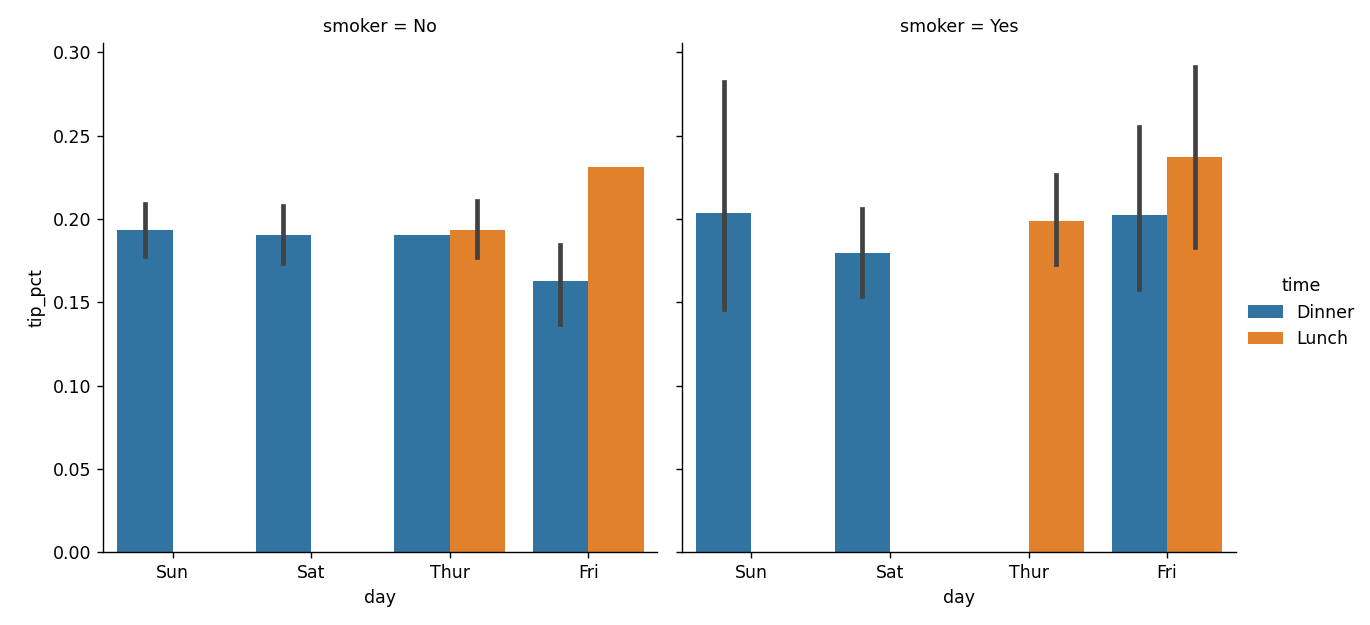

In [24]:
sns.factorplot(x='day', y='tip_pct', hue='time', col='smoker',
               kind='bar', data=tips[tips.tip_pct < 1])

# tips[tips.tip_pct < 1] คือการ select rows โดยการใช้ boolean Series

Instead of grouping by `'time'` by different bar colors within a facet, we can also
expand the facet grid by adding one **row** per `time` value

C:\Users\Lenovo\miniconda3\envs\4book\lib\site-packages\seaborn\categorical.py:3717: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


<IPython.core.display.Javascript object>


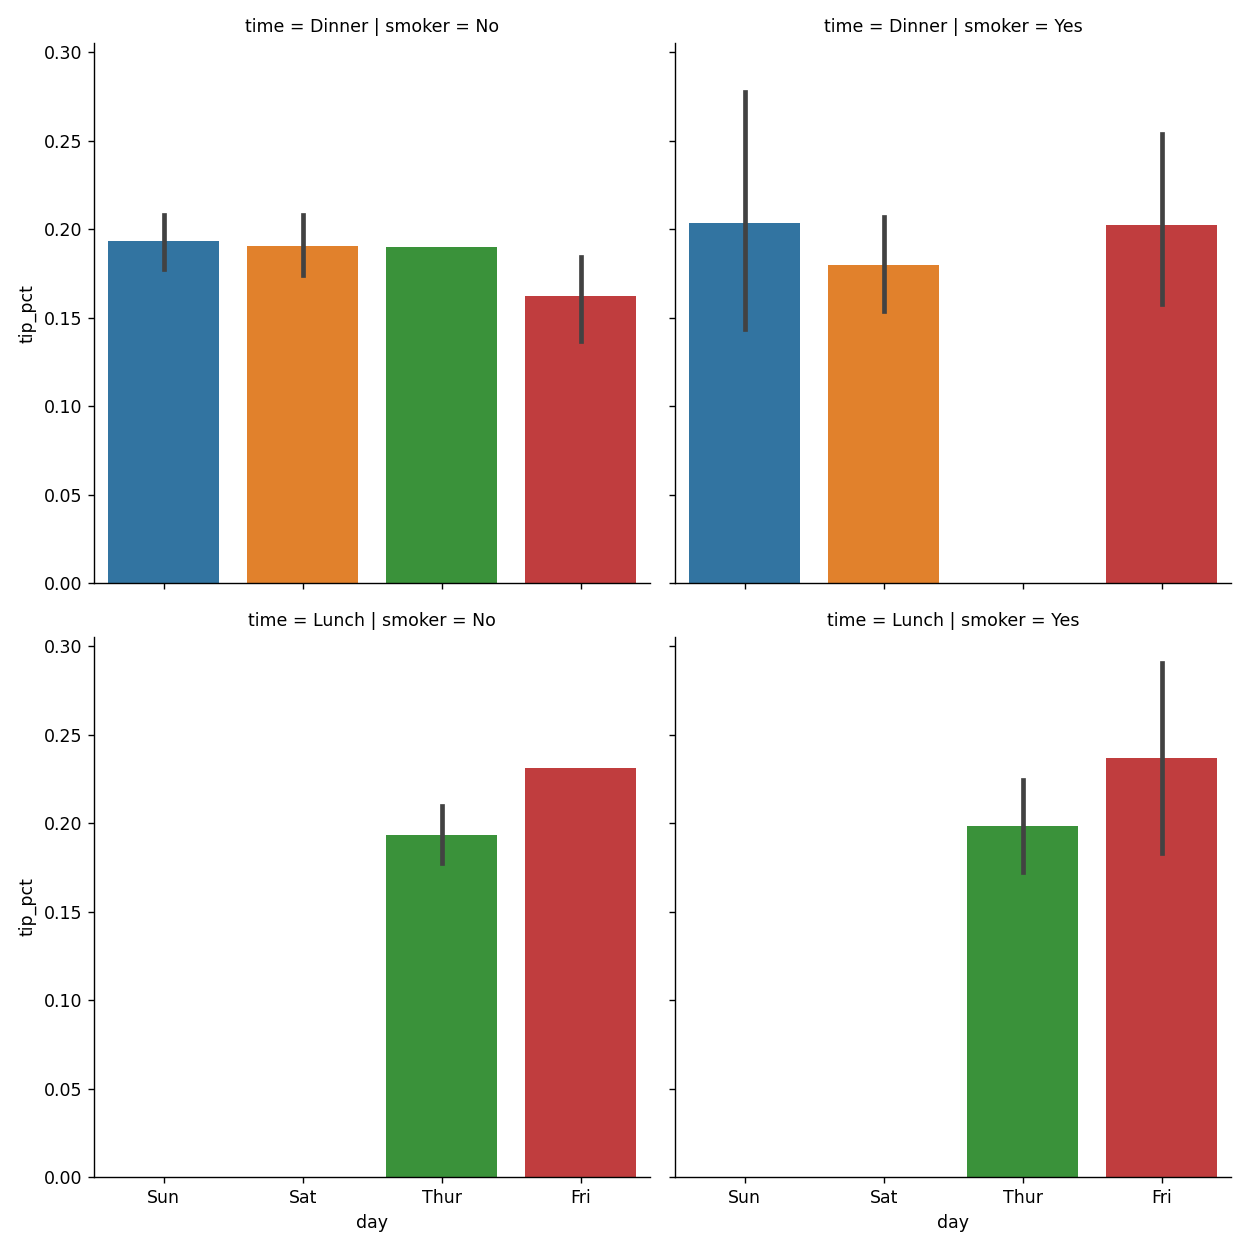

In [25]:
sns.factorplot(x='day', y='tip_pct', row='time',
               col='smoker',
               kind='bar', data=tips[tips.tip_pct < 1])

`factorplot` supports other plot types that may be useful depending on what you are
trying to display. For example, box plots (which show the median, quartiles, and outliers)
can be an effective visualization type

C:\Users\Lenovo\miniconda3\envs\4book\lib\site-packages\seaborn\categorical.py:3717: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


<IPython.core.display.Javascript object>


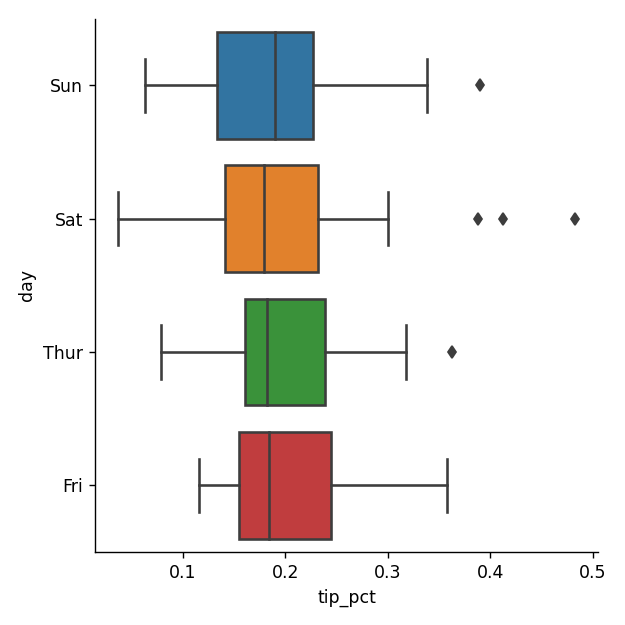

In [27]:
sns.factorplot(x='tip_pct', y='day', kind='box',
               data=tips[tips.tip_pct < 0.5])

<IPython.core.display.Javascript object>


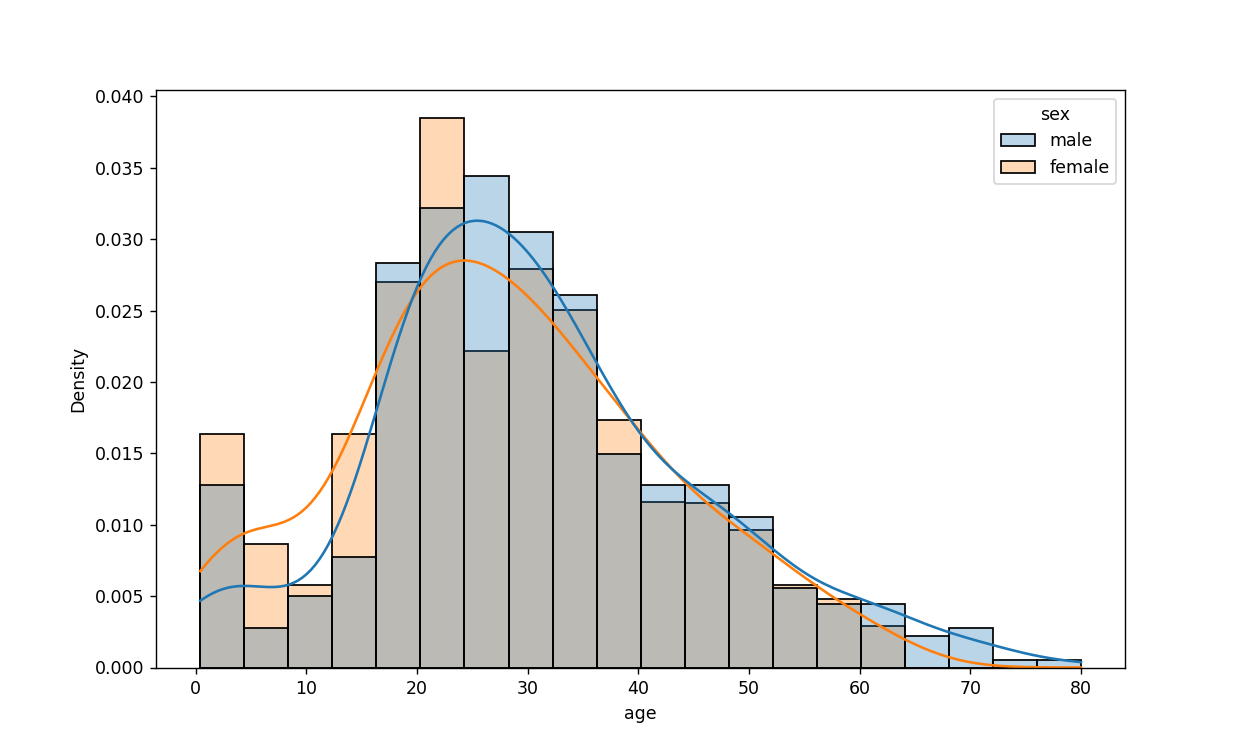

<AxesSubplot:xlabel='age', ylabel='Density'>

In [26]:
#ลองเอง เอามาจาก gemini

df = sns.load_dataset('titanic')

# Create the overlapping KDE plot
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='age', # The continuous variable to plot the distribution of
    hue='sex', # The categorical variable (group) to separate the distributions
    kde=True, # Display the Kernel Density Estimate (KDE) curve
    stat='density', # Normalize bars to show overall density
    common_norm=False, # **Crucial:** Allows each KDE curve to be normalized independently
    alpha=0.3 # Make the histograms partially transparent for better overlap visualization
)

## Other Python Visualization Tools

In [ ]:
pd.options.display.max_rows = PREVIOUS_MAX_ROWS

## Conclusion